# Que hace que un post tenga potencial de exito autentico?

## Enfoque sin data leakage, parecido al flujo de mis companeros

La idea cambia levemente: no vamos a usar likes, shares, comments, impressions ni engagement como variables predictoras, porque esas metricas aparecen despues de publicado el post. En marketing eso seria fuga de informacion.

**Pregunta del notebook:** podemos anticipar si un post tendra exito autentico usando senales previas del contenido y del contexto?

**Target:** `authentic_success`, construido con alto engagement, sentimiento positivo y baja toxicidad.

**Features permitidas:** texto, plataforma, marca, fase de campana, idioma, dia/hora y rasgos simples del texto.

---
## 0. Librerias

In [1]:
# Si falta alguna libreria, ejecutar:
# %pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, KFold, train_test_split, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
print('Librerias cargadas')

Librerias cargadas


---
## ACTO 1 - Carga de datos y definicion del objetivo

Usamos el dataset limpio de la primera evaluacion. Las metricas de resultado se usan solo para construir el target y para interpretar resultados, no como variables predictoras.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/Programación Ev2/proyecto_modelado')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'No existe la carpeta del proyecto: {PROJECT_ROOT}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for folder in [
    "data/raw", "data/interim", "data/processed", "plots",
    "reports", "results/metrics", "models/trained_models"
]:
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "social_media_enriched.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontró el archivo: {DATA_PATH}')

df = pd.read_csv(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head()

Mounted at /content/drive


In [ ]:
if 'total_interactions' not in df.columns and {'likes_count','shares_count','comments_count'}.issubset(df.columns):
    df['total_interactions'] = df['likes_count'] + df['shares_count'] + df['comments_count']

df['log_engagement'] = np.log10(df['engagement_rate'].clip(lower=0) + 1)
umbral_engagement = df['engagement_rate'].quantile(0.75)
umbral_toxicidad = df['toxicity_score'].quantile(0.40)

engagement_alto = df['engagement_rate'] >= umbral_engagement
sentimiento_positivo = df['sentiment_score'] > 0
toxicidad_baja = df['toxicity_score'] <= umbral_toxicidad
df['authentic_success'] = (engagement_alto & sentimiento_positivo & toxicidad_baja).astype(int)

print('Umbral engagement P75:', round(umbral_engagement, 4))
print('Umbral toxicidad P40:', round(umbral_toxicidad, 4))
display(df['authentic_success'].value_counts(normalize=True).mul(100).round(2).rename('porcentaje'))

Umbral engagement P75: 0.1631
Umbral toxicidad P40: 0.4026


authentic_success
0    94.69
1     5.31
Name: porcentaje, dtype: float64

### Auditoria anti-leakage

Esta tabla separa lo que se puede usar para anticipar una estrategia de marketing y lo que no. Si una variable solo existe despues de publicar, no debe entrar como feature.

In [ ]:
prohibidas_leakage = [
    'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate',
    'total_interactions', 'er_recalc', 'er_normalized', 'er_segment', 'composite_score',
    'sentiment_score', 'toxicity_score', 'sentiment_label', 'toxicity_bin',
    'authentic_success', 'log_engagement'
]
permitidas_contexto = [
    'text_content', 'platform', 'brand_name', 'campaign_phase', 'language',
    'day_of_week', 'hour', 'month', 'country_norm', 'platform_norm'
]
auditoria = pd.DataFrame({
    'tipo': ['permitida'] * len(permitidas_contexto) + ['prohibida_leakage'] * len(prohibidas_leakage),
    'columna': permitidas_contexto + prohibidas_leakage,
})
auditoria['existe_en_df'] = auditoria['columna'].isin(df.columns)
auditoria

,tipo,columna,existe_en_df
0,permitida,text_content,True
1,permitida,platform,True
2,permitida,brand_name,True
3,permitida,campaign_phase,True
4,permitida,language,True
5,permitida,day_of_week,True
6,permitida,hour,True
7,permitida,month,True
8,permitida,country_norm,True
9,permitida,platform_norm,True


**Conclusion:** la etiqueta se construye con engagement, sentimiento y toxicidad, pero el modelo intenta anticiparla con informacion previa del post. Asi evitamos que el modelo aprenda el resultado usando el resultado.

---
## ACTO 2 - Features de marketing antes de publicar

Creamos variables simples que una marca si podria conocer o controlar antes de publicar: largo del texto, cantidad de palabras, hashtags, menciones, signos de pregunta/exclamacion, plataforma y contexto de campana.

In [ ]:
df_model = df.copy()
df_model['text_content'] = df_model.get('text_content', '').fillna('').astype(str)
df_model['hashtags'] = df_model.get('hashtags', '').fillna('').astype(str)
df_model['mentions'] = df_model.get('mentions', '').fillna('').astype(str)

df_model['text_len'] = df_model['text_content'].str.len()
df_model['word_count'] = df_model['text_content'].str.split().str.len().fillna(0)
df_model['hashtag_count'] = df_model['hashtags'].str.count('#')
df_model['mention_count'] = df_model['mentions'].str.count('@')
df_model['has_question'] = df_model['text_content'].str.contains(r'\?', regex=True).astype(int)
df_model['has_exclamation'] = df_model['text_content'].str.contains('!', regex=False).astype(int)

cat_features = [c for c in ['platform', 'brand_name', 'campaign_phase', 'language', 'day_of_week', 'country_norm'] if c in df_model.columns]
num_features = [c for c in ['hour', 'month', 'text_len', 'word_count', 'hashtag_count', 'mention_count', 'has_question', 'has_exclamation'] if c in df_model.columns]
text_feature = 'text_content'

features = [text_feature] + cat_features + num_features
X = df_model[features].copy()
y_clf = df_model['authentic_success'].copy()
y_reg = df_model['log_engagement'].copy()

print('Features usadas sin leakage:', features)
print('Features prohibidas usadas:', [c for c in prohibidas_leakage if c in features])

---
## ACTO 3 - No supervisado: temas y tipos de contenido

Siguiendo la logica de mis companeros, el no supervisado se usa para descubrir estructura en el contenido. TF-IDF transforma el texto en numeros, TruncatedSVD reduce dimensionalidad y K-Means agrupa posts parecidos.

In [ ]:
tfidf_unsup = TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=2, stop_words='english')
X_text = tfidf_unsup.fit_transform(df_model['text_content'])
svd = TruncatedSVD(n_components=20, random_state=RANDOM_STATE)
X_cluster = svd.fit_transform(X_text)

resultados_k = []
for k in [3, 4, 5, 6, 8]:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    resultados_k.append({'k': k, 'silhouette': silhouette_score(X_cluster, labels), 'inertia': km.inertia_})
tabla_k = pd.DataFrame(resultados_k).sort_values('silhouette', ascending=False)
mejor_k = int(tabla_k.iloc[0]['k'])
kmeans = KMeans(n_clusters=mejor_k, n_init=10, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_cluster)

dbscan = DBSCAN(eps=0.8, min_samples=20)
db_labels = dbscan.fit_predict(X_cluster)
noise_rate = (db_labels == -1).mean()

display(tabla_k)
print('Mejor k:', mejor_k)
print('Outliers DBSCAN:', round(noise_rate * 100, 2), '%')

,k,silhouette,inertia
4,8,0.211283,1389.394720
3,6,0.192029,1564.430922
2,5,0.174810,1678.513777
0,3,0.156653,1952.814423
1,4,0.154317,1807.117293


Mejor k: 8
Outliers DBSCAN: 0.0 %


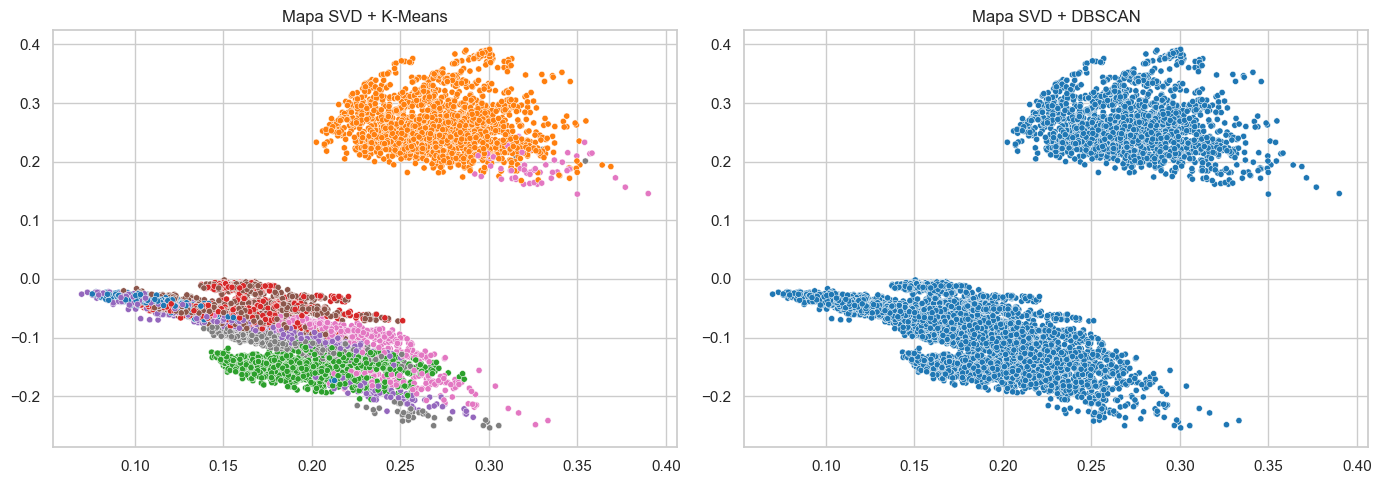

In [ ]:
pca_xy = X_cluster[:, :2]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=pca_xy[:,0], y=pca_xy[:,1], hue=clusters, palette='tab10', s=20, ax=axes[0], legend=False)
axes[0].set_title('Mapa SVD + K-Means')
sns.scatterplot(x=pca_xy[:,0], y=pca_xy[:,1], hue=db_labels, palette='tab10', s=20, ax=axes[1], legend=False)
axes[1].set_title('Mapa SVD + DBSCAN')
plt.tight_layout(); plt.show()

In [ ]:
terminos = np.array(tfidf_unsup.get_feature_names_out())
df_model['cluster'] = clusters
print('Terminos principales por cluster:')
for cluster_id in sorted(df_model['cluster'].unique()):
    mask_cluster = (df_model['cluster'].to_numpy() == cluster_id)
    centro = np.asarray(X_text[mask_cluster].mean(axis=0)).ravel()
    top_idx = centro.argsort()[-8:][::-1]
    top_terms = ', '.join(terminos[top_idx])
    print(f'Cluster {cluster_id}: {top_terms}')

cluster_perf = df_model.groupby('cluster')[['authentic_success', 'engagement_rate']].mean().round(4)
display(cluster_perf)
print('Conclusion: los clusters describen temas o formas de contenido; luego revisamos cual tiene mas exito autentico.')

Terminos principales por cluster:
Cluster 0: experienced, battery, experienced battery, battery problems, problems, service, customer service, experienced customer
Cluster 1: really, really interested, thoughts, hearing thoughts, interested, interested hearing, hearing, wait coming
Cluster 2: let know, know think, know, think, let, pepsi, wait coming, wait
Cluster 3: curious, curious experience, experience, wait, coming, wait coming, pepsi, yesterday
Cluster 4: new, unboxed new, just unboxed, unboxed, just, pepsi, quality, worth
Cluster 5: love, love feedback, feedback, review, pepsi, wait coming, coming, wait
Cluster 6: coca, coca cola, cola, cola coca, coke, cola vanilla, vanilla, cola cherry
Cluster 7: saw, ad, saw ad, just saw, just, ad samsung, ad adidas, ad nike


,authentic_success,engagement_rate
cluster,,
0,0.0538,0.2591
1,0.0568,0.3029
2,0.0551,0.2687
3,0.0414,0.2792
4,0.0575,0.3072
5,0.0506,0.2737
6,0.0617,0.2642
7,0.0535,0.2434


Conclusion: los clusters describen temas o formas de contenido; luego revisamos cual tiene mas exito autentico.


---
## ACTO 4 - Clasificacion sin leakage

Ahora entrenamos modelos para anticipar `authentic_success` usando solo texto y contexto. La metrica principal es F1-macro porque los posts exitosos son pocos.

In [ ]:
preprocesador = ColumnTransformer([
    ('texto', TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=2, stop_words='english'), text_feature),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
])

to_dense = FunctionTransformer(lambda z: z.toarray() if hasattr(z, 'toarray') else z, accept_sparse=True)

modelos_clf = {
    'Logistic Regression': Pipeline([('prep', preprocesador), ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))]),
    'SVM lineal': Pipeline([('prep', preprocesador), ('model', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('prep', preprocesador), ('dense', to_dense), ('model', RandomForestClassifier(n_estimators=120, class_weight='balanced', random_state=RANDOM_STATE))]),
    'Gradient Boosting': Pipeline([('prep', preprocesador), ('dense', to_dense), ('model', GradientBoostingClassifier(random_state=RANDOM_STATE))]),
}

cv_clf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resultados_clf = []
for nombre, modelo in modelos_clf.items():
    scores = cross_validate(modelo, X, y_clf, cv=cv_clf, scoring=['accuracy','precision_macro','recall_macro','f1_macro'], n_jobs=-1)
    resultados_clf.append({
        'modelo': nombre,
        'accuracy': scores['test_accuracy'].mean(),
        'precision_macro': scores['test_precision_macro'].mean(),
        'recall_macro': scores['test_recall_macro'].mean(),
        'f1_macro': scores['test_f1_macro'].mean(),
    })
tabla_clf = pd.DataFrame(resultados_clf).sort_values('f1_macro', ascending=False)
mejor_clf = tabla_clf.iloc[0]
tabla_clf

,modelo,accuracy,precision_macro,recall_macro,f1_macro
1,SVM lineal,0.756083,0.525362,0.590394,0.503743
0,Logistic Regression,0.720750,0.526939,0.607299,0.493606
3,Gradient Boosting,0.945583,0.538387,0.502257,0.491990
2,Random Forest,0.946833,0.473456,0.499956,0.486345


### Grafico de modelos supervisados y matriz de confusion

Primero graficamos las metricas principales para comparar los clasificadores. Luego entrenamos el mejor modelo en una particion `train/test` y mostramos su matriz de confusion.

La matriz de confusion permite ver cuatro casos: verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. En este problema es especialmente importante mirar la clase 1, porque los posts autenticamente exitosos son pocos.

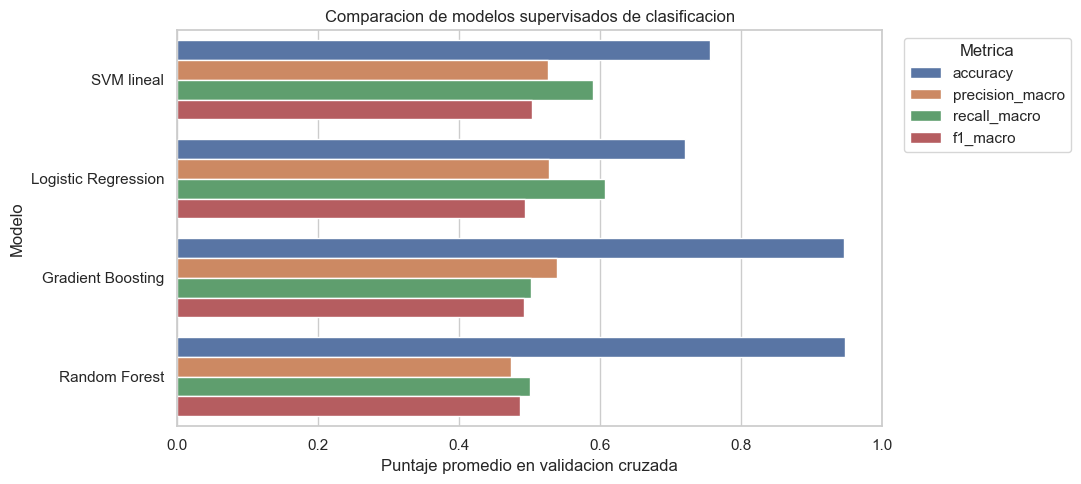

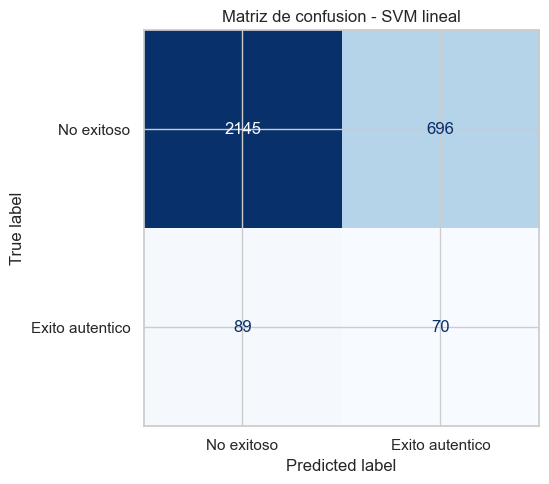

Mejor modelo supervisado: SVM lineal

Reporte de clasificacion en test:
                 precision    recall  f1-score   support

     No exitoso      0.960     0.755     0.845      2841
Exito autentico      0.091     0.440     0.151       159

       accuracy                          0.738      3000
      macro avg      0.526     0.598     0.498      3000
   weighted avg      0.914     0.738     0.809      3000

Conclusion: si hay muchos falsos negativos, el modelo esta perdiendo posts que si eran exitosos. Si hay muchos falsos positivos, esta recomendando posts como exitosos cuando no lo son.


In [ ]:
metricas_plot = tabla_clf.melt(
    id_vars='modelo',
    value_vars=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    var_name='metrica',
    value_name='valor'
)

plt.figure(figsize=(11, 5))
sns.barplot(data=metricas_plot, x='valor', y='modelo', hue='metrica')
plt.title('Comparacion de modelos supervisados de clasificacion')
plt.xlabel('Puntaje promedio en validacion cruzada')
plt.ylabel('Modelo')
plt.xlim(0, 1)
plt.legend(title='Metrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

mejor_nombre_clf = str(mejor_clf['modelo'])
modelo_matriz = modelos_clf[mejor_nombre_clf]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.25, stratify=y_clf, random_state=RANDOM_STATE
)
modelo_matriz.fit(X_train, y_train)
y_pred = modelo_matriz.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No exitoso', 'Exito autentico'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title(f'Matriz de confusion - {mejor_nombre_clf}')
plt.tight_layout()
plt.show()

print('Mejor modelo supervisado:', mejor_nombre_clf)
print('\nReporte de clasificacion en test:')
print(classification_report(y_test, y_pred, target_names=['No exitoso', 'Exito autentico'], digits=3))
print('Conclusion: si hay muchos falsos negativos, el modelo esta perdiendo posts que si eran exitosos. Si hay muchos falsos positivos, esta recomendando posts como exitosos cuando no lo son.')

### Interpretacion de la matriz de confusion y comparacion de modelos

La comparacion de modelos debe leerse usando principalmente `F1-macro`, no `accuracy`. Como solo cerca del 5.31% de los posts son `authentic_success = 1`, un modelo puede obtener accuracy alta prediciendo casi todo como "no exitoso". Por eso Random Forest y Gradient Boosting aparecen con accuracy cercana a 0.95, pero su F1-macro queda bajo: no estan capturando bien la clase minoritaria.

El mejor modelo por F1-macro fue `SVM lineal`. Su matriz de confusion en el conjunto de test muestra:

- Verdaderos negativos: posts no exitosos correctamente clasificados.
- Falsos positivos: posts que el modelo recomienda como exitosos, pero no lo eran.
- Falsos negativos: posts exitosos que el modelo no detecta.
- Verdaderos positivos: posts exitosos correctamente detectados.

Esta matriz es clave para negocio: un falso positivo puede hacer que una marca confie en una pieza que probablemente no funcionara; un falso negativo puede hacer que se descarte un post con potencial real.


In [ ]:
# Tabla resumida de la matriz de confusion ya calculada
cm_resumen = pd.DataFrame(
    cm,
    index=['Real: no exitoso', 'Real: exito autentico'],
    columns=['Predicho: no exitoso', 'Predicho: exito autentico']
)
display(cm_resumen)

# Version porcentual por clase real
cm_pct = cm_resumen.div(cm_resumen.sum(axis=1), axis=0).mul(100).round(2)
display(cm_pct)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_resumen, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusion - conteos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Valor real')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de confusion - porcentaje por clase real')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Valor real')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos negativos: {tn}')
print(f'Falsos positivos: {fp}')
print(f'Falsos negativos: {fn}')
print(f'Verdaderos positivos: {tp}')
print()
print('Lectura de negocio:')
print(f'- El modelo detecto {tp} de {tp + fn} posts autenticamente exitosos en test.')
print(f'- Tambien marco {fp} posts como exitosos cuando realmente no lo eran.')
print('- Esto confirma que el modelo sirve como apoyo exploratorio, no como regla automatica para decidir campanas.')


NameError: name 'pd' is not defined

---
## ACTO 5 - Regresion sin leakage

La regresion estima `log_engagement`, pero usando solo texto y contexto. Es mas dificil que predecir engagement con likes o impressions, pero es mas honesto para una estrategia previa a publicar.

**Nota practica:** esta parte usa una muestra reproducible para que no se demore demasiado en Visual Studio Code. La regresion con texto puede ponerse lenta porque cada palabra se transforma en columnas numericas.

In [ ]:
MAX_REG_ROWS = 3000
if len(X) > MAX_REG_ROWS:
    idx_reg = X.sample(n=MAX_REG_ROWS, random_state=RANDOM_STATE).index
    X_reg = X.loc[idx_reg].copy()
    y_reg_eval = y_reg.loc[idx_reg].copy()
else:
    X_reg = X.copy()
    y_reg_eval = y_reg.copy()

print(f'Regresion ejecutada sobre {len(X_reg):,} filas para evitar tiempos excesivos.')

preprocesador_reg = ColumnTransformer([
    ('texto', TfidfVectorizer(max_features=500, ngram_range=(1,1), min_df=2, stop_words='english'), text_feature),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_features),
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
])

modelos_reg = {
    'Ridge': Pipeline([('prep', preprocesador_reg), ('model', Ridge())]),
    'Lasso': Pipeline([('prep', preprocesador_reg), ('dense', to_dense), ('model', Lasso(alpha=0.001, max_iter=3000, random_state=RANDOM_STATE))]),
    'SVR lineal': Pipeline([('prep', preprocesador_reg), ('model', LinearSVR(random_state=RANDOM_STATE, max_iter=3000))]),
    'Random Forest Regressor': Pipeline([('prep', preprocesador_reg), ('dense', to_dense), ('model', RandomForestRegressor(n_estimators=40, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1))]),
}
cv_reg = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resultados_reg = []
for nombre, modelo in modelos_reg.items():
    print('Entrenando regresion:', nombre)
    scores = cross_validate(modelo, X_reg, y_reg_eval, cv=cv_reg, scoring=['neg_root_mean_squared_error','r2'], n_jobs=1)
    resultados_reg.append({'modelo': nombre, 'rmse': -scores['test_neg_root_mean_squared_error'].mean(), 'r2': scores['test_r2'].mean()})
tabla_reg = pd.DataFrame(resultados_reg).sort_values('rmse')
mejor_reg = tabla_reg.iloc[0]
tabla_reg

Regresion ejecutada sobre 3,000 filas para evitar tiempos excesivos.
Entrenando regresion: Ridge
Entrenando regresion: Lasso
Entrenando regresion: SVR lineal
Entrenando regresion: Random Forest Regressor


,modelo,rmse,r2
1,Lasso,0.129014,-0.005665
3,Random Forest Regressor,0.130646,-0.031281
2,SVR lineal,0.134143,-0.087080
0,Ridge,0.135729,-0.113544


---
## ACTO 6 - Optimizacion del modelo principal

In [ ]:
base_logreg = modelos_clf['Logistic Regression']
base_scores = cross_validate(base_logreg, X, y_clf, cv=cv_clf, scoring='f1_macro', n_jobs=-1)
f1_base = base_scores['test_score'].mean()

param_grid = {
    'prep__texto__max_features': [800, 1000, 1500],
    'prep__texto__ngram_range': [(1,1), (1,2)],
    'model__C': [0.5, 1.0, 2.0],
}
grid = GridSearchCV(base_logreg, param_grid=param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid.fit(X, y_clf)

param_random = {
    'prep__texto__max_features': [600, 800, 1000, 1500, 2000],
    'prep__texto__ngram_range': [(1,1), (1,2)],
    'model__C': loguniform(0.1, 5),
}
random_search = RandomizedSearchCV(base_logreg, param_distributions=param_random, n_iter=10, cv=3, scoring='f1_macro', random_state=RANDOM_STATE, n_jobs=-1)
random_search.fit(X, y_clf)

impacto_opt = pd.DataFrame({
    'modelo': ['Logistic Regression base', 'GridSearchCV', 'RandomizedSearchCV'],
    'f1_macro': [f1_base, grid.best_score_, random_search.best_score_],
})
display(impacto_opt)
print('Mejores parametros Grid:', grid.best_params_)
print('Mejores parametros Random:', random_search.best_params_)

,modelo,f1_macro
0,Logistic Regression base,0.493606
1,GridSearchCV,0.505986
2,RandomizedSearchCV,0.487083


Mejores parametros Grid: {'model__C': 2.0, 'prep__texto__max_features': 1500, 'prep__texto__ngram_range': (1, 2)}
Mejores parametros Random: {'model__C': np.float64(1.1196507183983258), 'prep__texto__max_features': 800, 'prep__texto__ngram_range': (1, 2)}


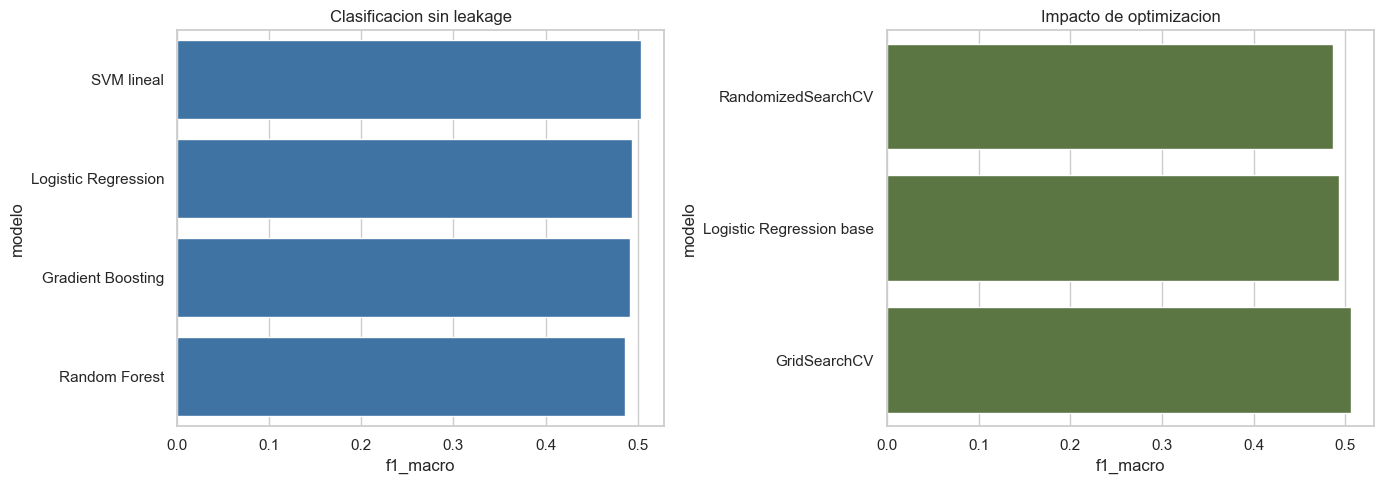

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=tabla_clf, x='f1_macro', y='modelo', ax=axes[0], color='#2E74B5')
axes[0].set_title('Clasificacion sin leakage')
sns.barplot(data=impacto_opt.sort_values('f1_macro'), x='f1_macro', y='modelo', ax=axes[1], color='#5A7D3B')
axes[1].set_title('Impacto de optimizacion')
plt.tight_layout(); plt.show()

---
## CIERRE EJECUTIVO

- **Insight corregido:** ahora el modelo no usa metricas posteriores al post como features. Usa texto y contexto, que son senales disponibles antes o al momento de publicar.
- **Clustering:** permite descubrir temas o tipos de contenido. No predice exito, ayuda a entender de que se habla.
- **Clasificacion:** predice si un post tiene potencial de exito autentico. La metrica clave es F1-macro por el desbalance.
- **Regresion:** intenta estimar engagement desde senales previas; es mas dificil, pero mas honesto que usar likes o impressions.
- **Marketing:** la recomendacion no es perseguir viralidad a cualquier costo, sino disenar contenido con buen potencial de engagement, tono positivo y baja toxicidad.
- **Limitaciones:** el target es una definicion operacional y no prueba causalidad. Como mejora futura se pueden ajustar umbrales por plataforma y agregar analisis mas profundo del texto.

In [ ]:
print('RESUMEN FINAL SIN LEAKAGE')
print('Mejor clasificador:', mejor_clf['modelo'], '| F1-macro:', round(mejor_clf['f1_macro'], 4))
print('Mejor regresor:', mejor_reg['modelo'], '| RMSE:', round(mejor_reg['rmse'], 4), '| R2:', round(mejor_reg['r2'], 4))
print('Mejor clustering k:', mejor_k, '| outliers DBSCAN:', round(noise_rate * 100, 2), '%')
print('Mejor optimizacion F1:', round(impacto_opt['f1_macro'].max(), 4))

RESUMEN FINAL SIN LEAKAGE
Mejor clasificador: SVM lineal | F1-macro: 0.5037
Mejor regresor: Lasso | RMSE: 0.129 | R2: -0.0057
Mejor clustering k: 8 | outliers DBSCAN: 0.0 %
Mejor optimizacion F1: 0.506


## Resumen final de resultados

El objetivo del notebook fue evaluar si se puede anticipar el **exito autentico** de un post usando solo informacion disponible antes de publicar. Para evitar **data leakage**, el modelo no uso likes, shares, comentarios, impressions, engagement, sentimiento ni toxicidad como variables predictoras. Esas variables solo se usaron para construir e interpretar el target.

El target `authentic_success` quedo muy desbalanceado: solo **5.31%** de los posts fueron considerados exitos autenticos, mientras que **94.69%** no lo fueron. Esto significa que el criterio es exigente: un post debe combinar alto engagement, sentimiento positivo y baja toxicidad.

En el analisis no supervisado, K-Means encontro como mejor opcion **k = 8**, con un silhouette aproximado de **0.2113**. Esto indica que existen algunos grupos de contenido, pero no estan fuertemente separados. DBSCAN no detecto outliers con la configuracion usada. Por lo tanto, el clustering ayuda a explorar temas o tipos de posts, pero no demuestra que un grupo especifico garantice el exito.

En los modelos supervisados, el mejor clasificador fue **SVM lineal**, con **F1-macro = 0.5037**. Aunque Random Forest y Gradient Boosting tuvieron accuracy cercana a 0.95, esa metrica es enganosa porque el dataset esta dominado por la clase no exitosa. Por eso la metrica mas importante es F1-macro, ya que evalua mejor el rendimiento en ambas clases.

La matriz de confusion del SVM lineal muestra que el modelo detecto **70 de 159** posts exitosos reales, pero tambien genero **696 falsos positivos** y perdio **89 falsos negativos**. Esto significa que el modelo encuentra parte de los posts con potencial, pero todavia no es suficientemente confiable para tomar decisiones automaticas.

**Conclusion general:** el exito autentico de un post no se puede anticipar con alta confianza usando solo texto y contexto previo. Los modelos muestran una senal debil o moderada, pero no un predictor fuerte. El valor del analisis esta en haberlo medido sin fuga de datos y en demostrar que el modelo sirve como apoyo exploratorio para marketing, no como una regla definitiva para decidir que publicar.
